# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 4, March 18th, 2025

# 1) Combining measurements

### $t\bar{t}$ cross section at $\sqrt{s} = 13.6\,$TeV

Both ATLAS and CMS have measured the cross section $\sigma(pp\rightarrow t\bar{t})$ at $\sqrt{s} = 13.6\,$TeV, where s should be the Mandelstam variable $-(p_1+p_2)^2$; in the CM frame it corresponds to the total energy squared.
The results are respectively $\sigma_{\rm{ATLAS}} = 850 \pm 3 (\rm{stat}) \pm 18 (\rm{syst}) \pm 20 (\rm{lumi})\,$pb ([Phys. Lett. B 848 (2024) 138376](https://doi.org/10.1016/j.physletb.2023.138376)) and $\sigma_{\rm{CMS}} = 881 \pm 23 (\rm{stat+syst}) \pm 20 (\rm{lumi})\,$pb ([JHEP 08 (2023) 204](https://doi.org/10.1007/JHEP08(2023)204)).

1. discuss the compatibility between the two results. Does it even make sense to combine them?

1. assuming that the uncertainties are gaussian and uncorrelated between both different components and different experiments, compute the estimate of $\sigma(pp\rightarrow t\bar{t})$ combining the results from ATLAS and CMS using the **Maximum Likelihood Method**

1. repeat the exercise above, now considering that the luminosity uncertainty is correlated between ATLAS and CMS. How do the combined value and its uncertainty change?

In [1]:
# 1.
data = {'atlas':{'value':850,
                 'error_sources':{'stat_err':3,
                                  'syst_err':18,
                                  'lumi_err':20},
                },

        'cms':{'value':881,
               'error_sources':{'stat_and_syst_err':23,
                                'lumi_err':20},
                },
       }

In [2]:
import numpy as np
from scipy.stats import chi2

weighted_mean = {'value':0,
                 'err':0,
                }

normalization = 0
for experiment in data:
    data[experiment]['err'] = 0
    for err_type in data[experiment]['error_sources']:
        data[experiment]['err'] += data[experiment]['error_sources'][err_type]**2
    data[experiment]['err'] = np.sqrt(data[experiment]['err'])
    
    normalization += 1/data[experiment]['err']**2    
    weighted_mean['value'] += data[experiment]['value']/data[experiment]['err']**2

weighted_mean['value'] = weighted_mean['value']/normalization
weighted_mean['err'] = np.sqrt(1/normalization)
weighted_mean['chi2'] = 0
for experiment in data:
    weighted_mean['chi2'] += (data[experiment]['value'] - weighted_mean['value'])**2/data[experiment]['err']**2
weighted_mean['red_chi2'] = weighted_mean['chi2']/len(data.keys())
weighted_mean['p-value'] = 1 - chi2.cdf( weighted_mean['chi2'], len(data.keys()) ) 

print(f'Given the small value of the reduced chi-squared {round(weighted_mean['red_chi2'],3)} and the high p-value {round(weighted_mean['p-value'],3)} \
of the weighted mean, it makes sense to average the two measurements as they are indeed compatible. The result is\n\
\tWeighted mean: {int(round(weighted_mean['value'],0))} pm {int(round(weighted_mean['err'],0))}')

Given the small value of the reduced chi-squared 0.289 and the high p-value 0.749 of the weighted mean, it makes sense to average the two measurements as they are indeed compatible. The result is
	Weighted mean: 864 pm 20


In [3]:
# 2.
from scipy.stats import norm
import matplotlib.pyplot as plt

means = np.linspace( min([data[experiment]['value'] for experiment in data])-20, max([data[experiment]['value'] for experiment in data])+20, int(1e4) ) 
L = []
for mean in means:
    L.append(1)
    for experiment in data:
        L[-1] *= norm.pdf( data[experiment]['value'], mean, data[experiment]['err'] ) # As standard deviation I am using the error on the value inferred experimentally
L = np.array(L)

index = np.argmax(L)
best_L = L[index]
MLE_mean = {'value':means[index]}
MLE_mean['chi2'] = 0
for experiment in data:
    MLE_mean['chi2'] += (data[experiment]['value'] - MLE_mean['value'])**2/data[experiment]['err']**2
MLE_mean['red_chi2'] = MLE_mean['chi2']/len(data.keys())
MLE_mean['p-value'] = 1 - chi2.cdf( MLE_mean['chi2'], len(data.keys()) )

min_L = best_L*np.exp(-0.5)
i = 0
while L[index+i] > min_L:
    i += 1
right_bound = means[index+i]
i = 0
while L[index-i] > min_L:
    i += 1
left_bound = means[index-i]
MLE_mean['err'] = max( right_bound-MLE_mean['value'], MLE_mean['value'] - left_bound )

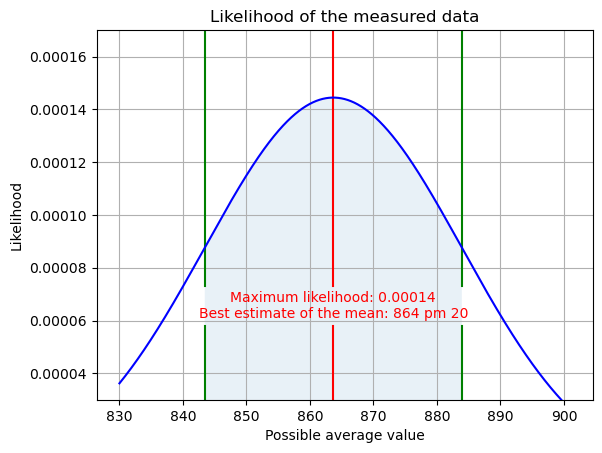

The difference between the weighted mean and the mean evaluated with the maximum likelihood method is
	(weighted mean)-(maximum likelihood mean) = 0.0005
The p-values of the two esitmates are
   Maximum Likelihood Estimate: 0.7489
                 Weighted mean: 0.7489
 The two results are identical.


In [4]:
plt.grid(1)
plt.title('Likelihood of the measured data')
plt.ylabel('Likelihood')
plt.xlabel('Possible average value')

plt.text(MLE_mean['value'],0.000061,f'Maximum likelihood: {round(best_L,5)}\nBest estimate of the mean: {round(MLE_mean['value'])} pm {int(round(MLE_mean['err']))}', color='red', ha='center')
plt.plot((MLE_mean['value'], MLE_mean['value']), (0.00003,0.000058), color='r')
plt.plot((MLE_mean['value'], MLE_mean['value']), (0.000073, 0.00017), color='r')

plt.plot((MLE_mean['value']+MLE_mean['err'], MLE_mean['value']+MLE_mean['err']), (0.00003,0.000058), color='g')
plt.plot((MLE_mean['value']+MLE_mean['err'], MLE_mean['value']+MLE_mean['err']), (0.000073, 0.00017), color='g')

plt.plot((MLE_mean['value']-MLE_mean['err'], MLE_mean['value']-MLE_mean['err']), (0.00003,0.000058), color='g')
plt.plot((MLE_mean['value']-MLE_mean['err'], MLE_mean['value']-MLE_mean['err']), (0.000073, 0.00017), color='g')

shaded_region = means[(means>MLE_mean['value']-MLE_mean['err']) & (means<MLE_mean['value']+MLE_mean['err'])]
shaded_curve = L[(means>MLE_mean['value']-MLE_mean['err']) & (means<MLE_mean['value']+MLE_mean['err'])]
plt.fill_between(shaded_region, np.zeros(len(shaded_region)), shaded_curve, alpha=0.1)

plt.plot(means, L, zorder=3, color='blue')
plt.ylim([0.00003, 0.00017])
plt.show()

print(f'The difference between the weighted mean and the mean evaluated with the maximum likelihood method is\n\
\t(weighted mean)-(maximum likelihood mean) = {round(weighted_mean['value'] - MLE_mean['value'],4)}\n\
The p-values of the two esitmates are\n',\
'Maximum Likelihood Estimate:'.rjust(30),f'{round(MLE_mean['p-value'],4)}\n',\
'Weighted mean:'.rjust(30),f'{round(weighted_mean['p-value'],4)}\n',\
'The two results are identical.')

In [5]:
# 3.
# The different errors that affect a measurement (stat, syst and lumi) can be seen as three random variables, all having mean
# equal to zero and standard deviation equal to stat_err, syst_err and lumi_err. Take just two of them for a simple visualization:
# we have stat defining a gaussian along the x axis, and lumi along the y axis. Their composite distribution in 2D is the product
# of the two gaussian: G(x,0,stat_err)*G(y,0,lumi_err). When they are uncorrelated, this results in an ellissoidal-gaussian that
# is not rotated. When they are correlated, this ellissoidal-gaussian is rotated. Usually we look at the distribution of their sum,
# z, we know it is again a gaussian with mean=0+0 and variance=stat_err**2+lumi_err**2 ! Graphically, G(z,0,z_err) is obtained
# integrating the composite distribution along the lines x+y=z where, z is the actual error that affects the measurement.
#
# If we now assume the lumi to be correlated in the two experiment, I understand that the random variable 'lumi', which is gaussian
# distributed around 0 with std lumi_err, takes the same value in both experiments. Than, what we obtain is a pdf of two random
# variables together: the two experimental results. The ATLAS suffers from its individual stat_and_syst_err and from the shared
# lumi_err, the CMS is affected by the shared lumi_err and its own sta_and_syst_err.
#
# So, given a possible value for the mean, its likelihood has to be computed as follows: |mean-ATLAS|=stat_and_syst_ATLAS+lumi_err
# |mean-CMS|=stat_and_syst_CMS+lumi_err. Then the likelihood is obtained as
#                            L = pdf(stat_and_syst_ATLAS)*pdf(stat_and_syst_CMS)*pdf(lumi_err)
# Of course, we have to account for all the possible combinations of the values of individual error sources that yield the same
# overall error. 

data['atlas']['error_sources']['stat_and_syst_err'] = (data['atlas']['error_sources']['stat_err']**2 + data['atlas']['error_sources']['syst_err']**2)**0.5

lumi_err_step = 0.1
means = np.linspace( min([data[experiment]['value'] for experiment in data])-20, max([data[experiment]['value'] for experiment in data])+20, int(1e3) )
L = []
for mean in means:
    total_err_ATLAS = abs(data['atlas']['value'] - mean)
    total_err_CMS = abs(data['cms']['value'] - mean)
    
    L.append(0)
    # Positive values of lumi_err
    lumi_err = 0
    while lumi_err < data['cms']['error_sources']['lumi_err']*3:
        L_contribution = norm.pdf(lumi_err, 0, data['cms']['error_sources']['lumi_err'])*norm.pdf(total_err_ATLAS-lumi_err, 0, data['atlas']['error_sources']['stat_and_syst_err'])*norm.pdf(total_err_CMS-lumi_err, 0, data['cms']['error_sources']['stat_and_syst_err'])
        L[-1] += L_contribution
        lumi_err += lumi_err_step # As we get further from 0, the contribution to L should decrease

    # Negative values of lumi_err
    lumi_err = 0
    while lumi_err > -data['cms']['error_sources']['lumi_err']*3:
        L_contribution = norm.pdf(lumi_err, 0, data['cms']['error_sources']['lumi_err'])*norm.pdf(total_err_ATLAS-lumi_err, 0, data['atlas']['error_sources']['stat_and_syst_err'])*norm.pdf(total_err_CMS-lumi_err, 0, data['cms']['error_sources']['stat_and_syst_err'])
        L[-1] += L_contribution
        lumi_err -= lumi_err_step # As we get further from 0, the contribution to L should decrease
L = np.array(L)

In [6]:
index = np.argmax(L)
best_L = L[index]
MLE_mean = {'value':means[index]}
MLE_mean['chi2'] = 0
for experiment in data:
    MLE_mean['chi2'] += (data[experiment]['value'] - MLE_mean['value'])**2/data[experiment]['err']**2
MLE_mean['red_chi2'] = MLE_mean['chi2']/len(data.keys())
MLE_mean['p-value'] = 1 - chi2.cdf( MLE_mean['chi2'], len(data.keys()) )

min_L = best_L*np.exp(-0.5)
i = 0
while L[index+i] > min_L:
    i += 1
right_bound = means[index+i]
i = 0
while L[index-i] > min_L:
    i += 1
left_bound = means[index-i]
MLE_mean['err'] = max( right_bound-MLE_mean['value'], MLE_mean['value'] - left_bound )

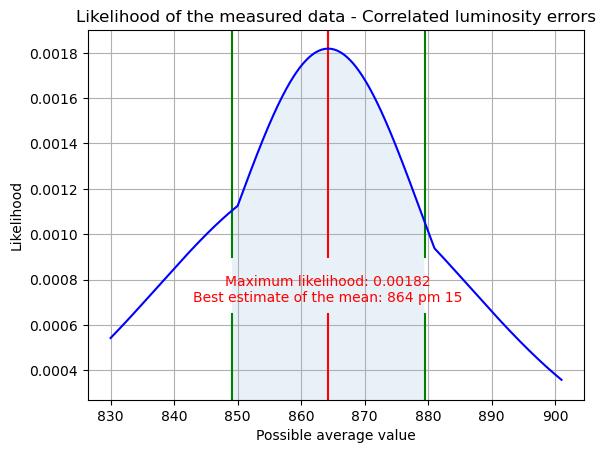

The difference between the weighted mean and the mean evaluated with the maximum likelihood method is
	(weighted mean)-(maximum likelihood mean) = -0.5842
The p-values of the two esitmates are
   Maximum Likelihood Estimate: 0.7486
                 Weighted mean: 0.7489
 The weighted mean has a slightly higher p-vaue. The MLE has lower uncertainty.


In [7]:
plt.grid(1)
plt.title('Likelihood of the measured data - Correlated luminosity errors')
plt.ylabel('Likelihood')
plt.xlabel('Possible average value')

plt.text(MLE_mean['value'],0.0007,f'Maximum likelihood: {round(best_L,5)}\nBest estimate of the mean: {round(MLE_mean['value'])} pm {int(round(MLE_mean['err']))}', color='red', ha='center')
plt.plot((MLE_mean['value'], MLE_mean['value']), (0.00025,0.00065), color='r')
plt.plot((MLE_mean['value'], MLE_mean['value']), (0.0009, 0.002), color='r')

plt.plot((MLE_mean['value']+MLE_mean['err'], MLE_mean['value']+MLE_mean['err']), (0.00025,0.00065), color='g')
plt.plot((MLE_mean['value']+MLE_mean['err'], MLE_mean['value']+MLE_mean['err']), (0.0009, 0.002), color='g')

plt.plot((MLE_mean['value']-MLE_mean['err'], MLE_mean['value']-MLE_mean['err']), (0.00025,0.00065), color='g')
plt.plot((MLE_mean['value']-MLE_mean['err'], MLE_mean['value']-MLE_mean['err']), (0.0009, 0.002), color='g')

shaded_region = means[(means>MLE_mean['value']-MLE_mean['err']) & (means<MLE_mean['value']+MLE_mean['err'])]
shaded_curve = L[(means>MLE_mean['value']-MLE_mean['err']) & (means<MLE_mean['value']+MLE_mean['err'])]
plt.fill_between(shaded_region, np.zeros(len(shaded_region)), shaded_curve, alpha=0.1)

plt.plot(means, L, zorder=3, color='blue')
plt.ylim([0.00027, 0.0019])
plt.show()

print(f'The difference between the weighted mean and the mean evaluated with the maximum likelihood method is\n\
\t(weighted mean)-(maximum likelihood mean) = {round(weighted_mean['value'] - MLE_mean['value'],4)}\n\
The p-values of the two esitmates are\n',\
'Maximum Likelihood Estimate:'.rjust(30),f'{round(MLE_mean['p-value'],4)}\n',\
'Weighted mean:'.rjust(30),f'{round(weighted_mean['p-value'],4)}\n',\
'The weighted mean has a slightly higher p-vaue. The MLE has lower uncertainty.')


# 2) 2D max likelihood fit

An experiment recorded 20 events of the process $\mathrm{B}_{\mathrm{s}}\to \mu^\pm\mu^\mp$.
Two observables are measured, the dimuon invariant mass and the decay length, i.e. the distance travelled by the $\mathrm{B}_{\mathrm{s}}$ meson before decaying. The data are reported below, the mass is given in MeV and the decay length in millimiters.
The mass experimental resolution is 30 MeV and constant for all events, the instrinsic width of the $\mathrm{B}_{\mathrm{s}}$ meson is negligible relative to experimental resolution.

```
           mass  decay_length
0   5342.990629      0.129966
1   5370.098405      0.313469
2   5391.762131      0.951778
3   5373.248764      0.157752
4   5421.216001      0.303553
5   5378.464940      0.068252
6   5413.543450      0.547077
7   5330.830304      0.306358
8   5399.754153      0.354952
9   5395.380538      0.029269
10  5395.408818      0.882227
11  5384.344397      0.410669
12  5395.233445      0.348704
13  5342.018296      0.010897
14  5348.767873      0.917650
15  5311.968224      1.828611
16  5303.544724      0.076058
17  5415.554657      0.537094
18  5394.132595      0.873480
19  5371.808143      0.573051
```
1. plot the 1D projections and 2D distributions. Are the two observables correlated? (this of the implication on the combined 2D pdf)
1. perform a 2-dimensional maximum likelihood fit to mass and decay length, following the example shown during lecture https://mdonega.github.io/hep-datanalysis-jb/interactive-nbs/MLMethod.html#interactive-example-ml-method-mean-of-a-gaussian
    1. to find the minimum of the negative log likelihood, performance a grid search with 10, 100, 1000 steps per axis (is this computationally efficient?). The initial scan ranges are 5000-5500 MeV and 0.1-1 mm (you can refine and tighten them after a first coarse scan)
    3. find the minimum NLL using `scipy.optimize.minimize`. Notice there exist several minimization algorithms, most do gradient descent some don't. Experiment yourself [docs](https://docs.scipy.org/doc/scipy/tutorial/optimize.html)
    4. tune the initial fit parameters and parameter ranges sensibly, otherwise the minimization won't converge. Use the distributions you plotted in the beginning for guidance.
3. compare the so found best-fit mass and lifetime to the values found in literature (use https://pdglive.lbl.gov/Viewer.action assume the heavy $\mathrm{B}_\mathrm{s}$ eigenstate)
4. compare the best-fit mass to the estimator of the mean of the dataset

Nota bene: the actual decay length is $L = \beta \gamma c t$, where $\beta$ and $\gamma$ are the particle velocity and Lorentz factor respectively, and $t$ is the decay time. For simplicity, albeit incorrect from a physics standpoint, assume $\beta=\gamma=1$. We call "lifetime" the decay constant of the exponential decay $e^{-t/\tau}$, or, correspondingly $e^{-L/c\tau}$

In [70]:
# Data loading
import numpy as np
data = {'mass':{'values':[5342.990629,
                          5370.098405,
                          5391.762131,
                          5373.248764,
                          5421.216001,
                          5378.464940,
                          5413.543450,
                          5330.830304,
                          5399.754153,
                          5395.380538,
                          5395.408818,
                          5384.344397,
                          5395.233445,
                          5342.018296,
                          5348.767873,
                          5311.968224,
                          5303.544724,
                          5415.554657,
                          5394.132595,
                          5371.808143],
               },
        'decay_length':{'values':[0.129966,
                                  0.313469,
                                  0.951778,
                                  0.157752,
                                  0.303553,
                                  0.068252,
                                  0.547077,
                                  0.306358,
                                  0.354952,
                                  0.029269,
                                  0.882227,
                                  0.410669,
                                  0.348704,
                                  0.010897,
                                  0.917650,
                                  1.828611,
                                  0.076058,
                                  0.537094,
                                  0.873480,
                                  0.573051],
                       },
       }
data['mass']['uncertainty'] = 30
data['decay_length']['uncertainty'] = 1 #The instructions were not clear. I assumed "the instrinsic width of the  meson is
                                        #negligible relative to experimental resolution" means that we have to consider as error
                                        #on the decay length only the experimental resolution. I tried with 0.0000001 but it failed
                                        #because it was too small so I am now using 1. This is not super relevant to find the MLE
                                        #but it does affect the uncertainty of the estimated parameter

  0%|          | 0/1 [00:00<?, ?it/s]

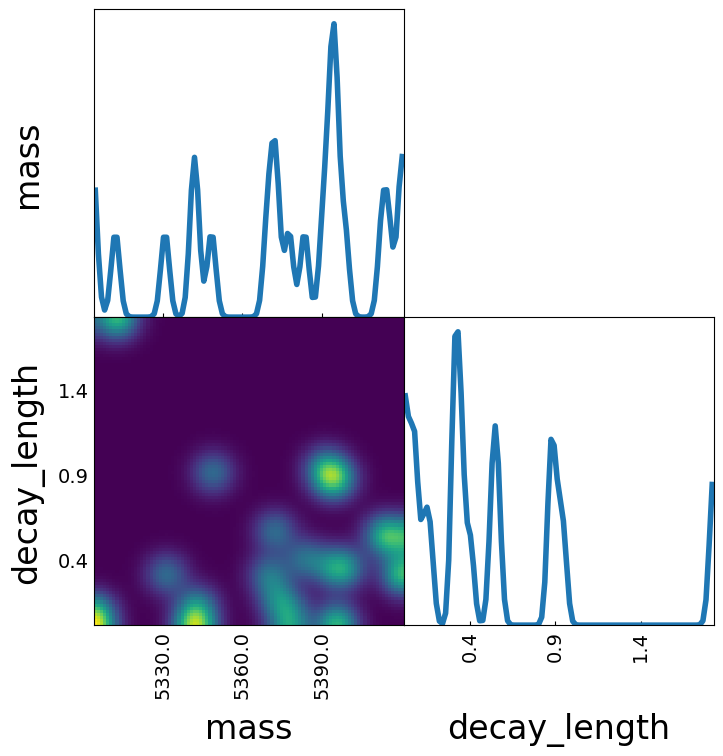

The two observables don't seem to be correlated


In [69]:
# 1.
from trianglechain import TriangleChain
import matplotlib.pyplot as plt
TriangleChain().density_image({key:data[key]['values'] for key in ['mass', 'decay_length']})
plt.show()
print("The two observables don't seem to be correlated")

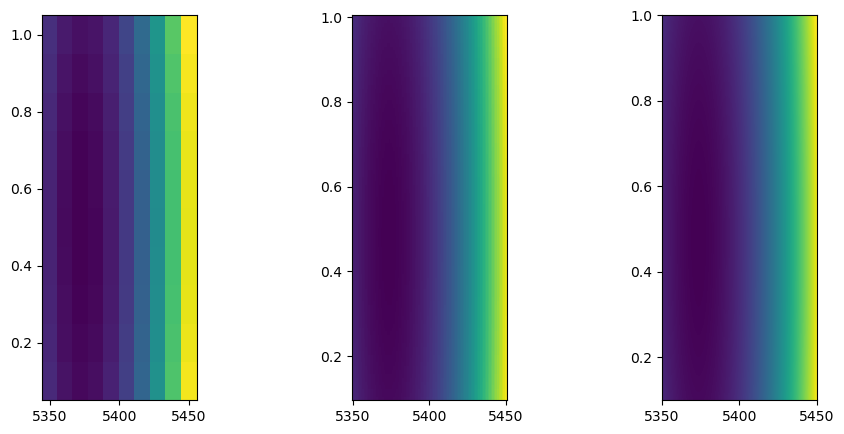

In [67]:
# 2.
import numpy as np
from scipy.stats import norm

steps = [10, 100, 1000]
NLL = {}
i = 0
plt.figure(figsize=(10,5))
for step in steps:
    NLL[step] = []
    masses = np.linspace(5350, 5450, step)
    decay_lengths = np.linspace(0.1, 1, step)
    for m in masses:
        NLL[step].append([])
        for dl in decay_lengths:
            NLL[step][-1].append( np.sum( -np.log( norm.pdf(data['mass']['values'], m, data['mass']['uncertainty']) * norm.pdf(data['decay_length']['values'], dl, data['decay_length']['uncertainty']) ) ) )
    NLL[step] = np.array(NLL[step])
    xgrid, ygrid = np.meshgrid(masses, decay_lengths)

    i += 1
    plt.subplot(1,3,i)
    plt.pcolor(xgrid, ygrid, NLL[step].T)
plt.subplots_adjust(wspace=1)
plt.show()

In [14]:
def compute_NLL(param, data):

    m = param[0]
    dl = param[1]
    NLL = np.sum( -np.log( norm.pdf(data['mass']['values'], m, data['mass']['uncertainty']) * norm.pdf(data['decay_length']['values'], dl, data['decay_length']['uncertainty']) ) ) 

    return NLL    

In [45]:
def compute_param_uncertainty(optimization_results, data):
    min_NLL = optimization_results.fun

    param_uncertainty = []
    i = 0
    for best_param in optimization_results.x:
        NLL = compute_NLL(optimization_results.x, data)
        step = optimization_results.hess_inv[i][i]*1e-3

        param = np.copy(optimization_results.x)
        while NLL < min_NLL+0.5:
            NLL = compute_NLL(param, data)
            param[i] += step
        print(NLL)
        right_bound = param[i] - optimization_results.x[i]

        param = np.copy(optimization_results.x)
        while NLL < min_NLL+0.5:
            NLL = compute_NLL(param, data)
            param[i] -= step
        left_bound = optimization_results.x[i] - param[i]
        
        param_uncertainty.append(max(left_bound, right_bound))
        i += 1

    return param_uncertainty

In [55]:
from scipy.optimize import minimize

initial_param = [5350,0.6]
optimization_results = minimize(lambda param: compute_NLL(param, data), initial_param, method='BFGS')
#print(optimization_results)

param_uncertainty = compute_param_uncertainty(optimization_results, data)
#print(param_uncertainty)
#print([np.sqrt(optimization_results.hess_inv[i][i]) for i in [0,1]])
print(f"The MLE for the mass of the meson is".ljust(50)+f"{str(optimization_results.x[0]).rjust(20)} pm  {str(param_uncertainty[0])}")
print(f"The MLE for the decay length of the meson is".ljust(50)+f"{str(optimization_results.x[1]).rjust(20)} pm  {str(param_uncertainty[1])}")

The MLE for the mass of the meson is                 5374.003580025122 pm  10.127203994694355
The MLE for the decay length of the meson is        0.4810433459937372 pm  0.09586797102213995


In [56]:
# 3.
# I tried, but there are way too many mesons called Bs

In [75]:
# 4.
print(f"The mean of the masses is".ljust(50)+f"{str(np.average(data['mass']['values'])).rjust(20)} pm {data['mass']['uncertainty']/np.sqrt(len(data['mass']['values']))}")
print("\nThe rough estimate with the aritmetic mean of the measured values is surprisingly accurate! It underestimates the\nuncertainty on the parameter but the two estimates are compatible")

The mean of the masses is                            5374.003524350001 pm 6.7082039324993685

The rough estimate with the aritmetic mean of the measured values is surprisingly accurate! It underestimates the
uncertainty on the parameter but the two estimates are compatible


# 3) Extended PDF

Before moving to a more realistic example (next exercise), let's implement an _extended_ ML fit to a simple normally distributed dataset.
That is, not only we want to estimate the mean and width of the normal distribution, we also want to estimate the yield.

1. generate 1000 normally distributed events, with $\mu=0$ and $\sigma=1$
2. write the extended NLL (hint: remember we want to _minimize_ the ENLL, are all terms needed?)
3. fit using `scipy.optimize.minimize` to estimate $N$, $\mu$, $\sigma$, where $N$ is the number of events
    1. be careful with initial parameters (don't pass it the exact parameters you used for generation, but don't give it nonsense numbers either)
    2. notice that $\sigma$ cannot be negative ==> you need to impose bounds 
5. estimate the uncertainties from the covariance matrix (hint: remember how it is related to the hessian. Hint: might need packages that do numerical derivative)
    1. what uncertainty do you expect for $N$?

In [84]:
# 1.
import numpy as np
from scipy.stats import norm
data = np.random.normal(0,1,1000)

\# 2.
The extended likelihood takes the following expression
\begin{equation}
EL = \frac{e^{-\lambda}\lambda^N}{N!} \cdot \prod_i^N f(x_i|\mu,\sigma)\;,
\end{equation}
therefore the ENLL becomes
\begin{equation}
ENLL = \lambda - N\log(\lambda) + \log(N!) - \sum_i^N \log\Bigl(f(x_i|\mu,\sigma)\Bigr);.
\end{equation}
Out of those terms, the third one is constant in the parameters we want to estimate ($\lambda, \mu, \sigma$) and thus it can be neglected when finding the minimum ENLL.

In [148]:
def compute_ENLL(param, data):

    lambd, mu, sigma = param

    ENLL = lambd - len(data)*np.log(lambd) - np.sum(np.log(norm.pdf(data,mu,sigma)))
    return ENLL

def compute_ENLL_single_parameter_wise(lambd, mu, sigma, data):
    param = [lambd, mu, sigma]
    return compute_ENLL(param, data)

In [146]:
from scipy.optimize import minimize
initial_param = [900, -0.5, 2] #[lambda, mu, sigma]
bounds = [[0,np.inf], [-np.inf,np.inf], [0, np.inf]]
optimization_results = minimize(lambda param: compute_ENLL(param, data), initial_param, method='Nelder-Mead', bounds=bounds)
print(optimization_results)
best_param = np.copy(optimization_results.x)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -4507.471678561489
             x: [ 1.000e+03  3.890e-02  9.815e-01]
           nit: 132
          nfev: 238
 final_simplex: (array([[ 1.000e+03,  3.890e-02,  9.815e-01],
                       [ 1.000e+03,  3.890e-02,  9.815e-01],
                       [ 1.000e+03,  3.890e-02,  9.815e-01],
                       [ 1.000e+03,  3.890e-02,  9.815e-01]]), array([-4.507e+03, -4.507e+03, -4.507e+03, -4.507e+03]))


In [191]:
from scipy.optimize import approx_fprime
hess = np.zeros((3,3))
epsilons = best_param*1e-3

hess[0, 0] = (approx_fprime(best_param[0], lambda y: (approx_fprime(y, lambda x: compute_ENLL_single_parameter_wise(x,best_param[1],best_param[2],data), epsilons[0]))[0], epsilons[0]))[0]
hess[0, 1] = (approx_fprime(best_param[0], lambda y: (approx_fprime(best_param[1], lambda x: compute_ENLL_single_parameter_wise(y,x,best_param[2],data), epsilons[1]))[0], epsilons[0]))[0]
hess[0, 2] = (approx_fprime(best_param[0], lambda y: (approx_fprime(best_param[2], lambda x: compute_ENLL_single_parameter_wise(y,best_param[1],x,data), epsilons[2]))[0], epsilons[0]))[0]
hess[1, 1] = (approx_fprime(best_param[1], lambda y: (approx_fprime(y, lambda x: compute_ENLL_single_parameter_wise(best_param[0],x,best_param[2],data), epsilons[1]))[0], epsilons[1]))[0]
hess[1, 2] = (approx_fprime(best_param[1], lambda y: (approx_fprime(best_param[2], lambda x: compute_ENLL_single_parameter_wise(best_param[0],y,x,data), epsilons[2]))[0], epsilons[1]))[0]
hess[2, 2] = (approx_fprime(best_param[2], lambda y: (approx_fprime(y, lambda x: compute_ENLL_single_parameter_wise(best_param[0],best_param[1],x,data), epsilons[2]))[0], epsilons[2]))[0]
hess[1, 0] = hess[0, 1]
hess[2, 0] = hess[0, 2]
hess[2, 1] = hess[1, 2]

hess_inv = np.linalg.inv(hess)
param_cov_matrix = 2*hess_inv
print(f"Estimate of the mean event number:".ljust(40)+str(best_param[0]).rjust(20)+" pm "+str(np.sqrt(param_cov_matrix[0][0])) )
print(f"Estimate of the mean:".ljust(40)+str(best_param[1]).rjust(20)+" pm "+str(np.sqrt(param_cov_matrix[1][1])) )
print(f"Estimate of the standard deviation:".ljust(40)+str(best_param[2]).rjust(20)+" pm "+str(np.sqrt(param_cov_matrix[2][2])) )

Estimate of the mean event number:          999.999998518354 pm 44.766069658242884
Estimate of the mean:                   0.038897028175011686 pm 0.04389481318832991
Estimate of the standard deviation:       0.9815179550523982 pm 0.031115963609409995


For $\lambda$ I would expect the uncertainty of a Poisson distribution with parameter $\lambda$, which is
\begin{equation}
\sigma_\lambda = \sqrt{\lambda} \sim 32
\end{equation}
for our case with $\lambda=1000$

# 4) Realistic case, extended fit, signal and background  

In this exercise you'll experiment with a realistic example similar to the simpler one discussed in exercise 2.  

The dataset `data.csv` contains the values of mass and decay length for signal which can be either signal or background.

1. load the dataset and plot 1D and 2D distributions
2. perform an extended max-likelihood fit to the 2D distribution mass x decay length
    1. the proportion between signal and background is unknown, but the total S + B yield must correspond to the number of events
    2. from the plotted distributions, make an educated guess on which PDFs to use for signal and background
    3. be careful with parameter bounds and initial guesses. This fit is more finicky than before...
    4. what's more, you might have to play with the minimizer's parameters, such that tolerance and gradient step size
    5. if the parameters have very different scales, this can create numerical instabilities (hint: to help convergencency, you might have to scale some parameters)
3. redo the 1D and 2D plots, overlay the fitted S+B function as well as the S and B components separately
4. estimate the uncertainties
5. "corner plot": plot all pairwise 2D NLL scans as well as the 1D marginal scans. Discuss whether any variables are correlated and try to explain why that happens by relating our observations to the characteristics of the 1D and 2D plots

In [1]:
# 1.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.optimize import minimize
from scipy.stats import norm

data = pd.read_csv('data.csv')

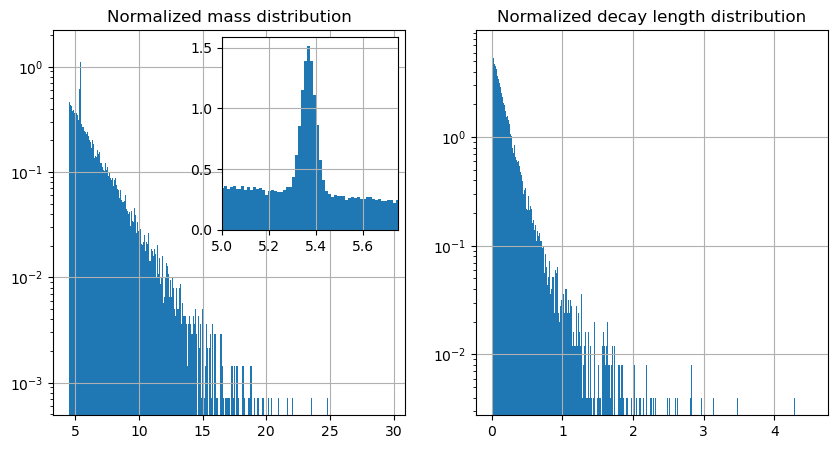

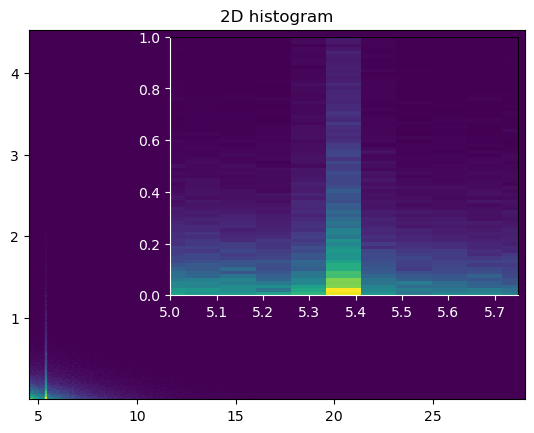

In [2]:
plt.figure(figsize=(10,5))
ax_mass = plt.subplot(1,2,1)
plt.hist(data['mass'], int(np.sqrt(len(data['mass']))*6), density=True)
plt.yscale('log')
plt.grid(1)
plt.title('Normalized mass distribution')
ax_zoom = inset_axes(ax_mass, width="50%", height="50%", loc="upper right")
ax_zoom.hist(data['mass'], int(np.sqrt(len(data['mass']))*6), density=True)
ax_zoom.grid(1)
ax_zoom.set_xlim((5,5.75))
ax_dl = plt.subplot(1,2,2)
plt.hist(data['decay_length'], int(np.sqrt(len(data['decay_length']))*6), density=True)
plt.yscale('log')
plt.grid(1)
plt.title('Normalized decay length distribution')
plt.show()

ax_2d = plt.subplot(1,1,1)
ax_2d.hist2d(data['mass'], data['decay_length'], int(np.sqrt(len(data['mass']))) )
ax_zoom = inset_axes(ax_2d, width="70%", height="70%", loc="upper right")
ax_zoom.hist2d(data['mass'], data['decay_length'], int(np.sqrt(len(data['mass']))) )
ax_zoom.set_xlim((5,5.75))
ax_zoom.set_ylim((0,1))
ax_zoom.tick_params(axis='x', colors='white')
ax_zoom.tick_params(axis='y', colors='white')
ax_zoom.spines['bottom'].set_color('white')
ax_zoom.spines['left'].set_color('white')
ax_2d.set_title('2D histogram')
plt.show()

In [2]:
# 2.
# From the plotted graphs (notice that the first two are in logarithmic scale but the inset zomm isn't) we can deduce that the
# background can be described by an exponential pdf, since the logarithmic plots are similar to straight lines. As for the signal,
# the zoom inside the first picture suggests that it may obey a gaussian distribution. As for the decay length, it seems simply
# an exponential without any other relevant structure
# So the parameters we need to estimate are (tau) and (nu) of the two exponentials, (mu, sigma) of the superimposed gaussian and
# the between the signal and the background (SB_ratio) such that our overall description of the data is
#                                             SB_ratio*Gaussian+(1-SB_ratio)*Exponential.

def m_background_pdf(m, tau, m_background_offset):
    pdf = 1/tau*np.exp(-(m-m_background_offset)/tau)
    return pdf

def dl_background_pdf(dl, nu):
    pdf = 1/nu*np.exp(-dl/nu)
    return pdf

def m_signal_pdf(m, mu, sigma):
    pdf = norm.pdf(m, mu, sigma)
    return pdf

In [3]:
def model_m_pdf(m,param):
    '''param = [tau, m_background_offset, nu, mu, sigma, SB_ratio]'''
    tau, m_background_offset, nu, mu, sigma, SB_ratio = param
    
    m_pdf = SB_ratio*m_signal_pdf(m, mu, sigma)+(1-SB_ratio)*m_background_pdf(m, tau, m_background_offset)
    return m_pdf

def model_dl_pdf(dl,param):
    '''param = [tau, m_background_offset, nu, mu, sigma, SB_ratio]'''
    tau, m_background_offset, nu, mu, sigma, SB_ratio = param

    dl_pdf= dl_background_pdf(dl, nu)
    return dl_pdf

def model_pdf(m,dl,param):
    '''param = [tau, m_background_offset, nu, mu, sigma, SB_ratio]'''
    tau, m_background_offset, nu, mu, sigma, SB_ratio = param
    
    m_pdf = model_m_pdf(m, param)
    dl_pdf= model_dl_pdf(dl,param)

    pdf = m_pdf*dl_pdf
    return pdf

In [4]:
def get_NLL(param, data):
    '''Here you can see the shift in prospective: the parameters are now the main variables and the data become fixed
    parameters that are given and never altered
    
    param = [tau, m_background_offset, nu, mu, sigma, SB_ratio]
    data['mass'] and data['decay_length'] are arrays of identical length'''

    print(param)
    with Pool(cpu_count()) as pool:
        NLLs = pool.starmap(model_pdf, [(m, dl, param) for m,dl in np.column_stack((data['mass'],data['decay_length']))])
    NLL = sum(-np.log(NLLs))
    
    #NLL = 0
    #for m,dl in np.column_stack((data['mass'],data['decay_length'])):
    #    NLL += -np.log(model_pdf(m,dl,param))
    
    return NLL

In [5]:
def minimize_NLL(initial_param, bounds, data):
    optimization_results = minimize(lambda param: get_NLL(param, data), initial_param, bounds=bounds, tol=1, method='Nelder-Mead')
    return optimization_results

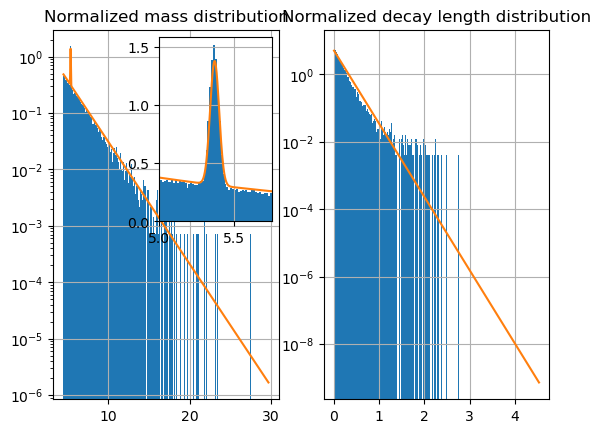

.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.
.


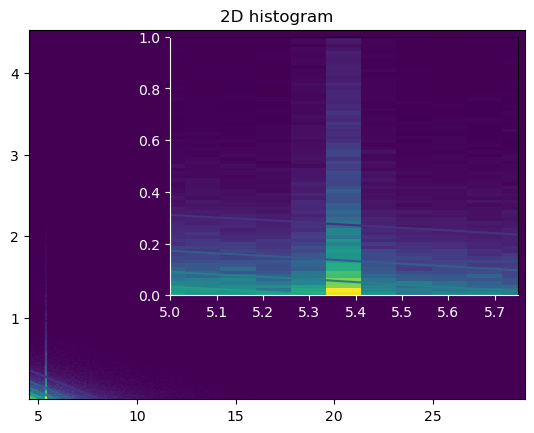

In [7]:
initial_tau = 2
initial_m_background_offset = 4.6
initial_nu = 0.2
initial_mu = 5.37
initial_sigma = 0.03
initial_SB_ratio = 0.08

initial_param = [initial_tau, initial_m_background_offset, initial_nu, initial_mu, initial_sigma, initial_SB_ratio]

ax_mass = plt.subplot(1,2,1)
plt.hist(data['mass'], int(np.sqrt(len(data['mass']))*6), density=True)
y = []
xs = np.linspace(min(data['mass']), max(data['mass']), int(1e4))
for x in xs:
    y.append(model_m_pdf(x,initial_param))
plt.plot(xs,y)
plt.yscale('log')
plt.grid(1)
plt.title('Normalized mass distribution')
ax_zoom = inset_axes(ax_mass, width="50%", height="50%", loc="upper right")
ax_zoom.hist(data['mass'], int(np.sqrt(len(data['mass']))*6), density=True)
ax_zoom.plot(xs,y)
ax_zoom.grid(1)
ax_zoom.set_xlim((5,5.75))
plt.subplot(1,2,2)
plt.hist(data['decay_length'], int(np.sqrt(len(data['decay_length']))*6), density=True)
y = []
xs = np.linspace(min(data['decay_length']), max(data['decay_length']), int(1e4))
for x in xs:
    y.append(model_dl_pdf(x,initial_param))
plt.plot(xs,y)
plt.yscale('log')
plt.grid(1)
plt.title('Normalized decay length distribution')
plt.show()

ax_2d = plt.subplot(1,1,1)
ax_2d.hist2d(data['mass'], data['decay_length'], int(np.sqrt(len(data['mass']))) )
xs = np.linspace(min(data['mass']), max(data['mass']), int(1e2))
ys = np.linspace(min(data['decay_length']), max(data['decay_length']), int(1e2))
z = []
for x in xs:
    z.append([])
    print('.')
    for y in ys:
        z[-1].append(model_pdf(x,y,initial_param))
X, Y = np.meshgrid(xs,ys)
z = np.array(z)
ax_2d.contour(X, Y, z.T)
ax_zoom = inset_axes(ax_2d, width="70%", height="70%", loc="upper right")
ax_zoom.hist2d(data['mass'], data['decay_length'], int(np.sqrt(len(data['mass']))) )
ax_zoom.contour(X, Y, z.T)
ax_zoom.set_xlim((5,5.75))
ax_zoom.set_ylim((0,1))
ax_zoom.tick_params(axis='x', colors='white')
ax_zoom.tick_params(axis='y', colors='white')
ax_zoom.spines['bottom'].set_color('white')
ax_zoom.spines['left'].set_color('white')
ax_2d.set_title('2D histogram')
plt.show()

In [ ]:
from multiprocessing import Pool, cpu_count, set_start_method
set_start_method("fork", force=True)

bounds = [[1,3],
          [4,6],
          [0.05,0.3],
          [5.3,5.42],
          [0.001, 0.1],
          [0.01,0.1]]

optimization_results = minimize_NLL(initial_param, bounds, data)
print(optimization_results)

[2.   4.6  0.2  5.37 0.03 0.08]
[2.1  4.6  0.2  5.37 0.03 0.08]
[2.   4.83 0.2  5.37 0.03 0.08]
[2.   4.6  0.21 5.37 0.03 0.08]
[2.   4.6  0.2  5.3  0.03 0.08]
[2.     4.6    0.2    5.37   0.0315 0.08  ]
[2.    4.6   0.2   5.37  0.03  0.084]
[2.03333333 4.67666667 0.20333333 5.42       0.0305     0.08133333]
[2.025    4.6575   0.2025   5.405    0.030375 0.081   ]
[2.04166667 4.69583333 0.19083333 5.38166667 0.030625   0.08166667]
[2.02222222 4.65111111 0.19444444 5.33888889 0.03033333 0.08088889]
[1.9212963  4.72564815 0.19509259 5.36351852 0.03081944 0.08218519]
[1.99506173 4.76753086 0.19345679 5.36135802 0.02909259 0.08291358]
[1.99341564 4.82337449 0.19127572 5.35847737 0.03029012 0.08388477]
[1.99012346 4.93506173 0.18691358 5.35271605 0.03043519 0.08582716]
[1.99012346 4.93506173 0.18691358 5.35271605 0.03043519 0.08049383]
[1.98518519 5.10259259 0.18037037 5.34407407 0.03065278 0.07874074]
[1.95555556 5.03444444 0.18777778 5.38555556 0.03020833 0.08288889]
[1.90740741 5.10259259